# BDC Satria Data 2026 — Klasifikasi Citra Sampah
### ViT-B/16 SWAG — Fokus: Training & Cari Model Akurasi Tinggi (belum predict test)

**Strategi split:**
- Holdout 10% (stratified) dari data train → disisihkan, dipakai sekali di akhir sebagai sanity check
- Sisa 90% → `StratifiedShuffleSplit(n_splits=3, test_size=0.10)` → tiap fold rasio train:val = 90:10
- Metrik utama: **Macro F1-Score** (bukan accuracy, karena kompetisi menilai pakai macro F1 dan kelas timpang)

**Catatan encoding label:** kita pakai label encoding integer (0/1/2), BUKAN one-hot manual.
Untuk `CrossEntropyLoss` (multi-class exclusive), integer label cuma dipakai sebagai index kelas oleh softmax —
tidak ada asumsi ordinal/hirarki antar kelas. One-hot manual justru butuh ganti ke `BCEWithLogitsLoss`
(biasa dipakai multi-*label*, bukan multi-*class* exclusive) dan tidak diperlukan di sini.


## 1. Setup & Konfigurasi

In [ ]:
from __future__ import annotations
import os
import json
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

In [3]:
# === PATH DATASET ===
# Sesuaikan kalau lokasi berbeda
DATA_ROOT = Path(r"D:\Downloads\BDC2026")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"          # belum dipakai di notebook ini
MODELS_DIR = DATA_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Folder kelas: prefix angka menentukan urutan label (0=Recyclable, 1=Electronic, 2=Organic)
CLASS_FOLDERS = ["0_Recyclable", "1_Electronic", "2_Organic"]
CLASS_NAMES = ["Recyclable", "Electronic", "Organic"]   # index sejajar dengan CLASS_FOLDERS
NUM_CLASSES = len(CLASS_NAMES)

# === CONFIG TRAINING ===
IMG_SIZE = 224
BATCH_SIZE = 16          # ViT-B/16 SWAG cukup berat, aman di RTX 3050 8GB dgn mixed precision
NUM_EPOCHS = 15          # backbone di-freeze -> konvergen cepat, cukup dgn epoch lebih sedikit dari 25
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 4             # early stopping berdasarkan macro F1 val
N_FOLDS = 3
HOLDOUT_FRAC = 0.10
FOLD_VAL_FRAC = 0.10
SEED = 42
NUM_WORKERS = 0          # di Windows/Jupyter set 0 dulu biar aman; boleh naikkan kalau run sbg .py script

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB


## 2. Index Dataset dari Folder
Kita **tidak** load semua gambar ke memory (26.527 citra terlalu besar). Cukup kumpulkan
daftar `(path, label_idx)` dulu — gambar di-load lazy per-batch lewat `Dataset`.

In [4]:
def index_dataset(train_dir: Path, class_folders: list[str]):
    records = []
    for label_idx, folder_name in enumerate(class_folders):
        folder = train_dir / folder_name
        if not folder.is_dir():
            raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        files = [p for p in folder.iterdir() if p.suffix.lower() in exts]
        for p in files:
            records.append({"path": str(p), "label": label_idx, "class_name": CLASS_NAMES[label_idx]})
    df = pd.DataFrame(records)
    return df

full_df = index_dataset(TRAIN_DIR, CLASS_FOLDERS)
print(f"Total citra ter-index: {len(full_df)}")
print(full_df["class_name"].value_counts())

Total citra ter-index: 26527
class_name
Organic       12567
Recyclable     9999
Electronic     3961
Name: count, dtype: int64


## 3. EDA Singkat — Distribusi Kelas

In [5]:
class_counts = full_df["class_name"].value_counts()
class_ratio = (class_counts / class_counts.sum() * 100).round(2)
summary = pd.DataFrame({"count": class_counts, "percent": class_ratio})
print(summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nRasio imbalance (mayoritas/minoritas): {imbalance_ratio:.2f}x")
print("-> Electronic adalah kelas minoritas, perlu class weighting saat training.")

            count  percent
class_name                
Organic     12567    47.37
Recyclable   9999    37.69
Electronic   3961    14.93

Rasio imbalance (mayoritas/minoritas): 3.17x
-> Electronic adalah kelas minoritas, perlu class weighting saat training.


In [6]:
# Cek beberapa contoh ukuran gambar (sanity check, bukan wajib)
sample_paths = full_df["path"].sample(5, random_state=SEED).tolist()
for p in sample_paths:
    with Image.open(p) as im:
        print(Path(p).name, im.size, im.mode)

O_11933.jpg (300, 168) RGB
O_12341.jpg (183, 275) RGB
R_553.jpg (297, 170) RGB
R_8278.jpg (275, 183) RGB
O_96.jpg (261, 193) RGB


## 4. Holdout Split (10%, stratified)
Disisihkan di awal, **tidak disentuh** sampai proses CV & tuning selesai.
Hanya dipakai sekali di akhir sebagai sanity check terakhir.

In [7]:
cv_pool_df, holdout_df = train_test_split(
    full_df,
    test_size=HOLDOUT_FRAC,
    stratify=full_df["label"],
    random_state=SEED,
)
cv_pool_df = cv_pool_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

print(f"CV pool (90%): {len(cv_pool_df)}")
print(f"Holdout (10%): {len(holdout_df)}  <- jangan dipakai sampai akhir")
print("\nDistribusi kelas di holdout:")
print(holdout_df['class_name'].value_counts())

# Simpan daftar holdout biar konsisten dipakai lagi nanti tanpa perlu re-split
holdout_df.to_csv(DATA_ROOT / "holdout_split.csv", index=False)

CV pool (90%): 23874
Holdout (10%): 2653  <- jangan dipakai sampai akhir

Distribusi kelas di holdout:
class_name
Organic       1257
Recyclable    1000
Electronic     396
Name: count, dtype: int64


## 5. 3-Fold StratifiedShuffleSplit (rasio 90/10 tiap fold)
Beda dengan `StratifiedKFold` biasa (rasio 67/33). Di sini tiap fold train:val = 90:10,
supaya training per fold lebih cepat karena porsi data train lebih besar.

In [8]:
sss = StratifiedShuffleSplit(n_splits=N_FOLDS, test_size=FOLD_VAL_FRAC, random_state=SEED)

fold_indices = list(sss.split(cv_pool_df, cv_pool_df["label"]))
for fold, (tr_idx, val_idx) in enumerate(fold_indices):
    print(f"Fold {fold+1}: train={len(tr_idx)} | val={len(val_idx)}")

Fold 1: train=21486 | val=2388
Fold 2: train=21486 | val=2388
Fold 3: train=21486 | val=2388


## 6. Transform & Dataset

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_transforms(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])


class TrashDataset(Dataset):
    """Dataset lazy-load dari dataframe (path, label)."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except (FileNotFoundError, OSError) as exc:
            raise FileNotFoundError(f"Tidak bisa baca gambar: {row['path']}") from exc

        if self.transform:
            img = self.transform(img)

        return img, int(row["label"])

## 7. Class Weights (untuk imbalance)

In [10]:
def compute_weights(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=labels,
    )
    return torch.tensor(weights, dtype=torch.float32)

## 8. Model — ViT-B/16 SWAG
Default: backbone di-freeze total, hanya classifier head yang dilatih (cepat, hemat VRAM,
dan cara ini yang terbukti bagus di project masakan Padang kamu — F1 0.95+).

Kalau nanti hasil head-only belum memuaskan, tinggal ubah `UNFREEZE_LAST_N_BLOCKS`
untuk fine-tune beberapa block terakhir encoder (lebih lambat & lebih boros VRAM,
turunkan BATCH_SIZE kalau OOM).

In [11]:
UNFREEZE_LAST_N_BLOCKS = 0   # 0 = head-only (default aman). Coba 1-2 kalau mau fine-tune lebih dalam.

def build_model(num_classes: int, unfreeze_last_n: int = 0):
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1)

    # Freeze semua dulu
    for param in model.parameters():
        param.requires_grad = False

    # Opsional: unfreeze beberapa encoder block terakhir
    if unfreeze_last_n > 0:
        total_blocks = len(model.encoder.layers)
        for layer in model.encoder.layers[total_blocks - unfreeze_last_n:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Ganti classifier head
    in_features = model.heads.head.in_features
    model.heads = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=in_features, out_features=num_classes, bias=True),
    )
    # Head selalu trainable
    for param in model.heads.parameters():
        param.requires_grad = True

    return model.to(DEVICE)

## 9. Training & Evaluasi (mixed precision + macro F1)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(DEVICE == "cuda")):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=(DEVICE == "cuda")):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_f1, np.array(all_preds), np.array(all_labels)

## 10. Training Loop — 3 Fold

In [13]:
fold_results = []

for fold, (tr_idx, val_idx) in enumerate(fold_indices):
    print("=" * 70)
    print(f"FOLD {fold + 1}/{N_FOLDS}")
    print("=" * 70)

    train_fold_df = cv_pool_df.iloc[tr_idx].reset_index(drop=True)
    val_fold_df = cv_pool_df.iloc[val_idx].reset_index(drop=True)
    print(f"  train: {len(train_fold_df)} | val: {len(val_fold_df)}")

    train_dataset = TrashDataset(train_fold_df, transform=get_transforms(train=True))
    val_dataset = TrashDataset(val_fold_df, transform=get_transforms(train=False))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))

    model = build_model(NUM_CLASSES, unfreeze_last_n=UNFREEZE_LAST_N_BLOCKS)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,}")

    class_w = compute_weights(train_fold_df["label"].values, NUM_CLASSES).to(DEVICE)
    print(f"  Class weights: {class_w.cpu().numpy().round(3)}")

    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR, weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )
    scaler = GradScaler(enabled=(DEVICE == "cuda"))

    best_f1 = 0.0
    epochs_no_improve = 0
    fold_model_path = MODELS_DIR / f"vit_fold{fold+1}_best.pth"

    start_time = time.time()
    for epoch in range(NUM_EPOCHS):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_f1, val_preds, val_labels = evaluate(model, val_loader, criterion)
        scheduler.step(val_f1)

        improved = val_f1 > best_f1
        if improved:
            best_f1 = val_f1
            epochs_no_improve = 0
            torch.save(model.state_dict(), fold_model_path)
        else:
            epochs_no_improve += 1

        marker = " *" if improved else ""
        print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
              f"train_loss {train_loss:.4f} train_f1 {train_f1:.4f} | "
              f"val_loss {val_loss:.4f} val_f1 {val_f1:.4f}{marker}")

        if epochs_no_improve >= PATIENCE:
            print(f"  Early stopping di epoch {epoch+1} (tidak improve {PATIENCE}x)")
            break

    elapsed = time.time() - start_time
    print(f"  Fold {fold+1} selesai dalam {elapsed/60:.1f} menit | Best macro F1: {best_f1:.4f}")

    # Load model terbaik fold ini utk classification report
    model.load_state_dict(torch.load(fold_model_path, weights_only=True))
    _, final_f1, final_preds, final_labels = evaluate(model, val_loader, criterion)
    print("\n  Classification report (val, model terbaik fold ini):")
    print(classification_report(final_labels, final_preds, target_names=CLASS_NAMES, zero_division=0))

    fold_results.append({
        "fold": fold + 1,
        "best_val_macro_f1": best_f1,
        "train_size": len(train_fold_df),
        "val_size": len(val_fold_df),
        "elapsed_minutes": elapsed / 60,
        "model_path": str(fold_model_path),
    })

    del model
    torch.cuda.empty_cache()

FOLD 1/3
  train: 21486 | val: 2388
  Trainable params: 2,307 / 85,800,963
  Class weights: [0.884 2.233 0.704]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\778915856.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE == "cuda"))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


  Epoch  1/15 | train_loss 0.1758 train_f1 0.9302 | val_loss 0.1057 val_f1 0.9605 *


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


  Epoch  2/15 | train_loss 0.1421 train_f1 0.9474 | val_loss 0.0981 val_f1 0.9652 *


...

  Epoch  8/15 | train_loss 0.1193 train_f1 0.9561 | val_loss 0.1199 val_f1 0.9601


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


  Epoch  9/15 | train_loss 0.1156 train_f1 0.9569 | val_loss 0.1174 val_f1 0.9594
  Early stopping di epoch 9 (tidak improve 4x)
  Fold 3 selesai dalam 44.2 menit | Best macro F1: 0.9609


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):



  Classification report (val, model terbaik fold ini):
              precision    recall  f1-score   support

  Recyclable       0.95      0.95      0.95       900
  Electronic       0.97      0.97      0.97       357
     Organic       0.96      0.96      0.96      1131

    accuracy                           0.96      2388
   macro avg       0.96      0.96      0.96      2388
weighted avg       0.96      0.96      0.96      2388



## 11. Ringkasan 3 Fold

In [14]:
results_df = pd.DataFrame(fold_results)
print(results_df)

mean_f1 = results_df["best_val_macro_f1"].mean()
std_f1 = results_df["best_val_macro_f1"].std()
print(f"\nRata-rata macro F1: {mean_f1:.4f} (+/- {std_f1:.4f})")

best_fold_row = results_df.loc[results_df["best_val_macro_f1"].idxmax()]
print(f"\nFold terbaik: Fold {int(best_fold_row['fold'])} dengan macro F1 = {best_fold_row['best_val_macro_f1']:.4f}")
print(f"Model path: {best_fold_row['model_path']}")

results_df.to_csv(DATA_ROOT / "fold_results_summary.csv", index=False)

   fold  best_val_macro_f1  train_size  val_size  elapsed_minutes  \
0     1           0.965240       21486      2388        33.907933   
1     2           0.964834       21486      2388        44.251905   
2     3           0.960861       21486      2388        44.161130   

                                       model_path  
0  D:\Downloads\BDC2026\models\vit_fold1_best.pth  
1  D:\Downloads\BDC2026\models\vit_fold2_best.pth  
2  D:\Downloads\BDC2026\models\vit_fold3_best.pth  

Rata-rata macro F1: 0.9636 (+/- 0.0024)

Fold terbaik: Fold 1 dengan macro F1 = 0.9652
Model path: D:\Downloads\BDC2026\models\vit_fold1_best.pth


   fold  val_accuracy  val_macro_f1  \
0     1      0.964824      0.965240   
1     2      0.961893      0.964834   
2     3      0.958961      0.960861   

                                       model_path  
0  D:\Downloads\BDC2026\models\vit_fold1_best.pth  
1  D:\Downloads\BDC2026\models\vit_fold2_best.pth  
2  D:\Downloads\BDC2026\models\vit_fold3_best.pth  


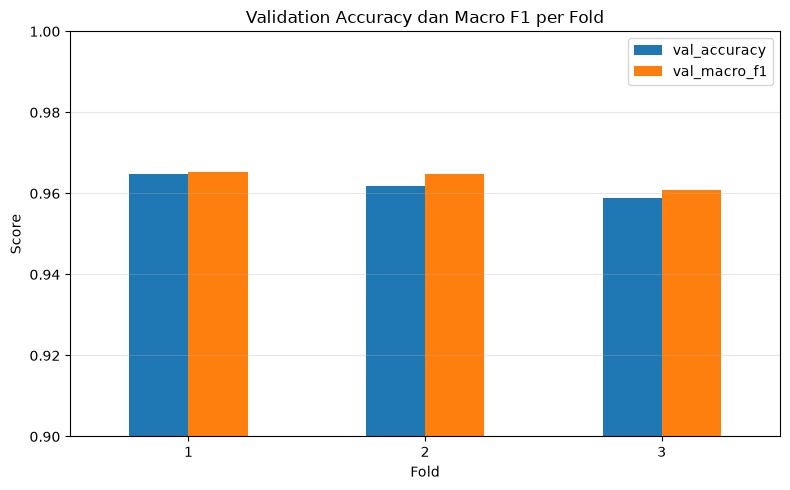

In [17]:
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

def eval_saved_fold(model_path: Path, val_df: pd.DataFrame):
    model = build_model(NUM_CLASSES, unfreeze_last_n=UNFREEZE_LAST_N_BLOCKS)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    loader = DataLoader(
        TrashDataset(val_df, transform=get_transforms(train=False)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
    )

    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average="macro")

fold_metrics = []
for fold_info, (tr_idx, val_idx) in zip(fold_results, fold_indices):
    val_df = cv_pool_df.iloc[val_idx].reset_index(drop=True)
    acc, f1 = eval_saved_fold(fold_info["model_path"], val_df)
    fold_metrics.append({
        "fold": fold_info["fold"],
        "val_accuracy": acc,
        "val_macro_f1": f1,
        "model_path": fold_info["model_path"],
    })

metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df)

fig, ax = plt.subplots(figsize=(8, 5))
metrics_df.set_index("fold")[["val_accuracy", "val_macro_f1"]].plot(
    kind="bar", ax=ax, rot=0, ylim=(0.9, 1.0)
)
ax.set_title("Validation Accuracy dan Macro F1 per Fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. (Nanti) Validasi ke Holdout Set
Jalankan bagian ini **setelah** kamu yakin dengan model/hyperparameter terbaik dari hasil 3-fold di atas.
Ini sanity check terakhir sebelum lanjut ke prediksi Data Uji resmi — jangan dipakai buat tuning lebih lanjut.

In [18]:

best_model = build_model(NUM_CLASSES, unfreeze_last_n=UNFREEZE_LAST_N_BLOCKS)
best_model.load_state_dict(torch.load(best_fold_row["model_path"], weights_only=True))

holdout_dataset = TrashDataset(holdout_df, transform=get_transforms(train=False))
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

criterion = nn.CrossEntropyLoss()
_, holdout_f1, holdout_preds, holdout_labels = evaluate(best_model, holdout_loader, criterion)
print(f"Holdout macro F1: {holdout_f1:.4f}")
print(classification_report(holdout_labels, holdout_preds, target_names=CLASS_NAMES, zero_division=0))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30740\287271888.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


Holdout macro F1: 0.9644
              precision    recall  f1-score   support

  Recyclable       0.95      0.96      0.95      1000
  Electronic       0.99      0.96      0.98       396
     Organic       0.97      0.96      0.97      1257

    accuracy                           0.96      2653
   macro avg       0.97      0.96      0.96      2653
weighted avg       0.96      0.96      0.96      2653

